# Analyse sur les truites de notre échantillon dans le but de généraliser à la population

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

sys.path.append(str(Path.cwd().parent)) # Ajoute le dossier parent au chemin de recherche de Python

from Methodo_volumes.calcul_volume_fct import calculate_areas
from utils.stats_fct import distribution, nuage_points, linear_regression, plot_evolution_curves

In [2]:
# ---- Importation du fichier avec les metadatas ----
file_path = '../utils/correspondance_echo_final.xlsx'
df = pd.read_excel(file_path, dtype={"image_id": str})

df = df[df.annee.isin([2019, 2024])] # Filtre pour le moment sur 2019 et 2024
unique_id = np.unique(df.cap_id)

## Vrais masques

### Récupère le vrai volume des gonades de l'échantillon

In [3]:
resultats = {"id poisson": [], "position echo": [], "surface_cavite": [], "surface_gonade": [], "volume_cavite": [], 
             "volume_gonade": [], "echelle": [], "augmentation_surface_gonade": [], "augmentation_surface_cavite": []}

In [4]:
# --- Calcul des volumes par poisson ----
for i, id in enumerate(unique_id): # parcours chaque poisson
    # On récupère les échographies associé au poisson
    echos = df[df.cap_id.isin([id])]
    
    # ---- On parcours chaque échographie ----
    last_row = None
    last_rayon_gonade = None
    last_rayon_cavite = None
    last_surface_gonade = None
    last_surface_cavite = None
    volumes_gonade_list = []
    volumes_cavite_list = []
    count = 0
    
    for index, row in echos.iterrows():
        file_path = row["new_name_file"]

        # --- Importation des images et des masques ---
        mask_path = f"../data/YOLO/labels/{file_path}.txt"
        image_path = f"../data/YOLO/images/{file_path}.jpg"

        if os.path.exists(mask_path) : # Vérifie si le fichier existe
            count += 1
            echelle = row["echelle"] # Récupère l'échelle de l'image

            # --- Calcul de la surface des gonades et de la cavité ---
            surface_gonade, surface_cavite = calculate_areas(mask_path, image_path, echelle)

            # ---- Calcul du rayon du cercle à partir des surfaces ----
            rayon_gonade = np.sqrt(surface_gonade/np.pi)
            rayon_cavite = np.sqrt(surface_cavite/np.pi)

            # ---- Calcul de l'augmentation (%) de la surface de la gonade par rapport à l'écho précédent du même poisson ----
            if last_row is not None :
                augmentation_surface_gonade = round((surface_gonade - last_surface_gonade) / last_surface_gonade * 100, 0)
                augmentation_surface_cavite = round((surface_cavite - last_surface_cavite) / last_surface_cavite * 100, 0)
            else :
                augmentation_surface_gonade = 0
                augmentation_surface_cavite = 0

            # ---- Calcul du volume des cônes ----
            if last_row is not None : # Si pas la première échographie
                distance = row["position"] - last_row["position"]

                volume_gonade = 1/3 * np.pi * (last_rayon_gonade**2 + rayon_gonade**2 + last_rayon_gonade * rayon_gonade) * distance # Formule d'un cône tronqué
                volume_cavite = 1/3 * np.pi * (last_rayon_cavite**2 + rayon_cavite**2 + last_rayon_cavite * rayon_cavite) * distance # Formule d'un cône tronqué

                volumes_gonade_list.append(volume_gonade)
                volumes_cavite_list.append(volume_cavite)

            last_row = row
            last_rayon_gonade = rayon_gonade
            last_rayon_cavite = rayon_cavite
            last_surface_gonade = surface_gonade
            last_surface_cavite = surface_cavite
            print(f"Position de l'écho : {row['position']}, surface gonades : {surface_gonade:.2f} cm2, rayon : {rayon_gonade:.2f} cm, surface cavité : {surface_cavite:.2f} cm2")

            resultats["id poisson"].append(id)
            resultats["position echo"].append(row["position"])
            resultats["surface_cavite"].append(surface_cavite)
            resultats["surface_gonade"].append(surface_gonade)
            resultats["echelle"].append(echelle)
            resultats["augmentation_surface_gonade"].append(augmentation_surface_gonade)
            resultats["augmentation_surface_cavite"].append(augmentation_surface_cavite)


    # --- Calcul du volume total des gonades et de la cavité ---
    if np.sum(volumes_gonade_list) != 0:
        # ---- Calcul du cône final ----
        volume_gonade = np.pi * rayon_gonade**2 * abs(row["position"] - row["long_gonade"]) / 3 # Formule d'un cône
        volumes_gonade_list.append(volume_gonade)

        volume_cavite = np.pi * rayon_cavite**2 * abs(row["position"] - row["long_gonade"]) / 3 # Formule d'un cône
        volumes_cavite_list.append(volume_cavite)

        # --- calcul volume final ----
        volume_total_gonade = np.sum(volumes_gonade_list)
        volume_total_cavite = np.sum(volumes_cavite_list)

        print(f"Poisson n°: {id}, Nombre d'échos : {count}/{len(echos)}, Volume total gonades: {volume_total_gonade:.2f} cm3, volume total cavité: {volume_total_cavite:.2f} cm3")
        print("-----------------------")

        resultats["volume_cavite"].extend([volume_total_cavite] * count) # Ajoute le volume total de la cavité pour chaque échographie
        resultats["volume_gonade"].extend([volume_total_gonade] * count)

    if count == 1:
        print("Pas assez d'échos pour calculer le volume des gonades.")
        print(f"Poisson n°: {id}, Nombre d'échos : {count}/{len(echos)}")
        print("-----------------------")
        volume_total_gonade = "NA"
        volume_total_cavite = "NA"

        resultats["volume_cavite"].append(0)
        resultats["volume_gonade"].append(0)


Position de l'écho : 1.0, surface gonades : 0.41 cm2, rayon : 0.36 cm, surface cavité : 1.34 cm2
Position de l'écho : 3.0, surface gonades : 0.43 cm2, rayon : 0.37 cm, surface cavité : 1.09 cm2
Position de l'écho : 4.0, surface gonades : 0.26 cm2, rayon : 0.29 cm, surface cavité : 0.56 cm2
Poisson n°: 356302, Nombre d'échos : 3/3, Volume total gonades: 1.45 cm3, volume total cavité: 3.82 cm3
-----------------------
Position de l'écho : 0.0, surface gonades : 0.74 cm2, rayon : 0.48 cm, surface cavité : 1.68 cm2
Position de l'écho : 2.0, surface gonades : 1.17 cm2, rayon : 0.61 cm, surface cavité : 1.89 cm2
Position de l'écho : 4.0, surface gonades : 0.99 cm2, rayon : 0.56 cm, surface cavité : 1.13 cm2
Position de l'écho : 6.0, surface gonades : 0.41 cm2, rayon : 0.36 cm, surface cavité : 0.60 cm2
Poisson n°: 356418, Nombre d'échos : 4/4, Volume total gonades: 5.73 cm3, volume total cavité: 8.70 cm3
-----------------------
Position de l'écho : 0.0, surface gonades : 0.95 cm2, rayon : 0.5

In [5]:
# Transformation du dictionnaire en DataFrame
df_res = pd.DataFrame.from_dict(resultats)
df_res.to_csv("true_volumes_ech.csv", index=False) # Sauvegarde du DataFrame en CSV
df_res

,id poisson,position echo,surface_cavite,surface_gonade,volume_cavite,volume_gonade,echelle,augmentation_surface_gonade,augmentation_surface_cavite
0,356302,1.0,1.335455,0.412763,3.824314,1.448392,3.1,0.0,0.0
1,356302,3.0,1.094686,0.425495,3.824314,1.448392,3.1,3.0,-18.0
2,356302,4.0,0.564342,0.261349,3.824314,1.448392,3.1,-39.0,-48.0
3,356418,0.0,1.680767,0.737942,8.699849,5.726512,3.8,0.0,0.0
4,356418,2.0,1.890160,1.172025,8.699849,5.726512,3.8,59.0,12.0
...,...,...,...,...,...,...,...,...,...
81,427276,2.0,2.159730,0.804122,11.408657,4.243235,3.8,237.0,-2.0
82,427276,4.0,1.709827,0.770433,11.408657,4.243235,3.8,-4.0,-21.0
83,427276,6.0,0.844237,0.511352,11.408657,4.243235,3.8,-34.0,-51.0
84,427305,2.0,1.988039,1.540853,3.514411,2.755696,3.8,0.0,0.0


## Graphiques pour visualiser l'évolution de la surface des gonades pour un meme poisson

In [6]:
#Compter le nombre de lignes par poisson
poisson_counts = df_res['id poisson'].value_counts()

# Filtrer les poissons avec exactement 2 lignes
poissons_2_lines = poisson_counts[poisson_counts == 2].index
df_2_lines = df_res[df_res['id poisson'].isin(poissons_2_lines)]

# Filtrer les poissons avec plus de 2 lignes
poissons_other = poisson_counts[poisson_counts > 2].index
df_other = df_res[df_res['id poisson'].isin(poissons_other)]

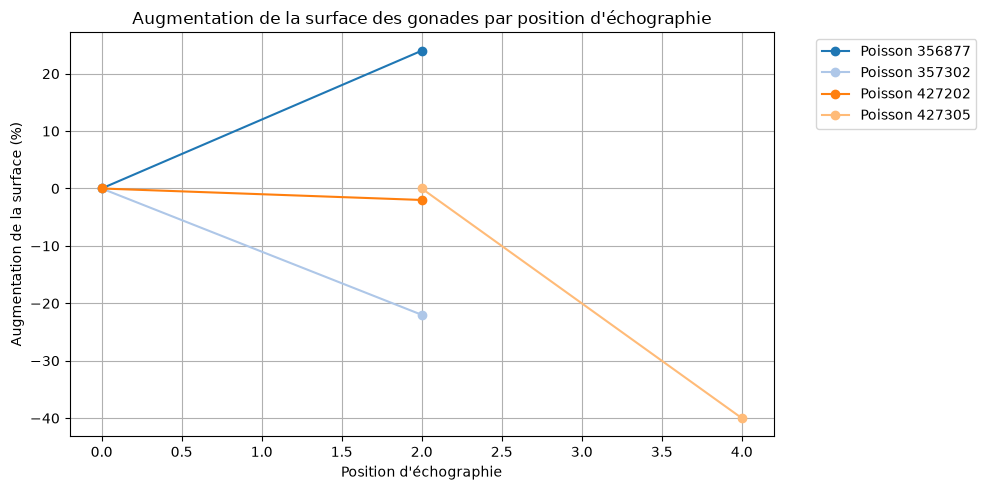

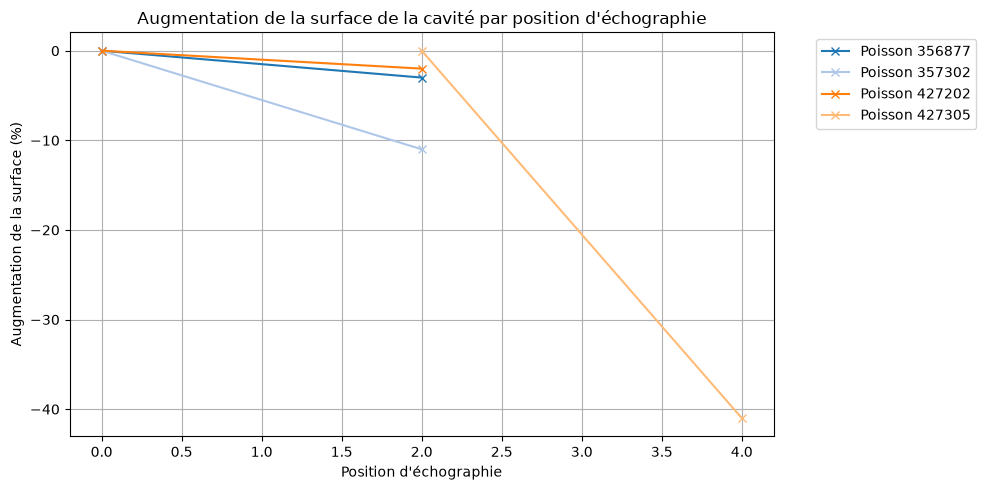

In [7]:
plot_evolution_curves(df_2_lines)

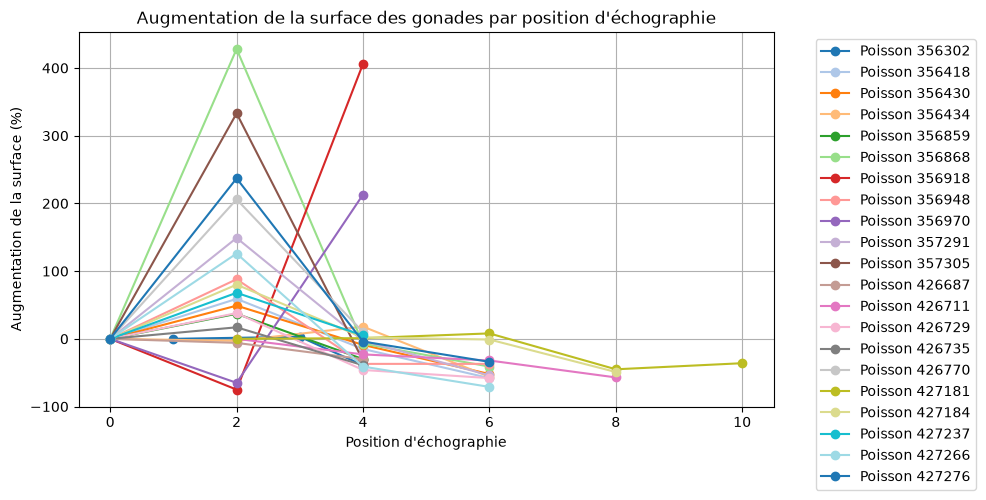

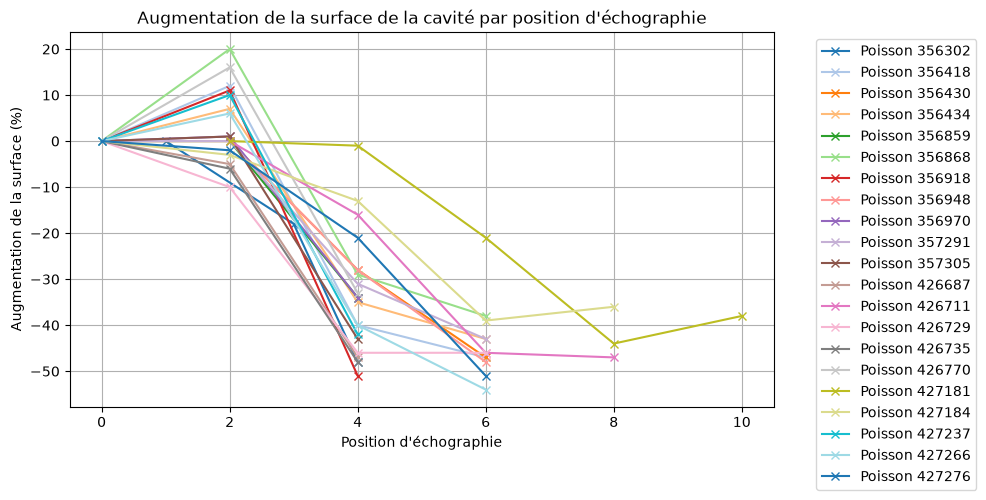

In [8]:
plot_evolution_curves(df_other)

## Graphique pour voir le lien entre les variables

Corrélation : 0.639690839578387


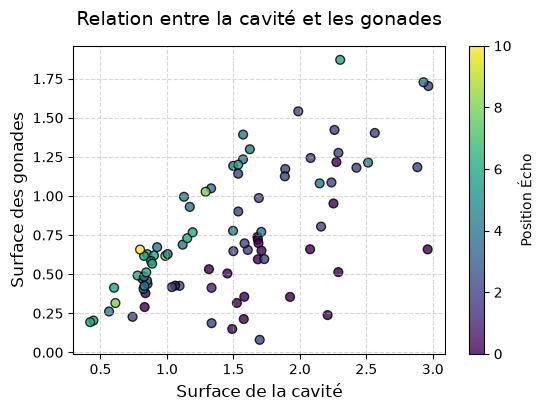

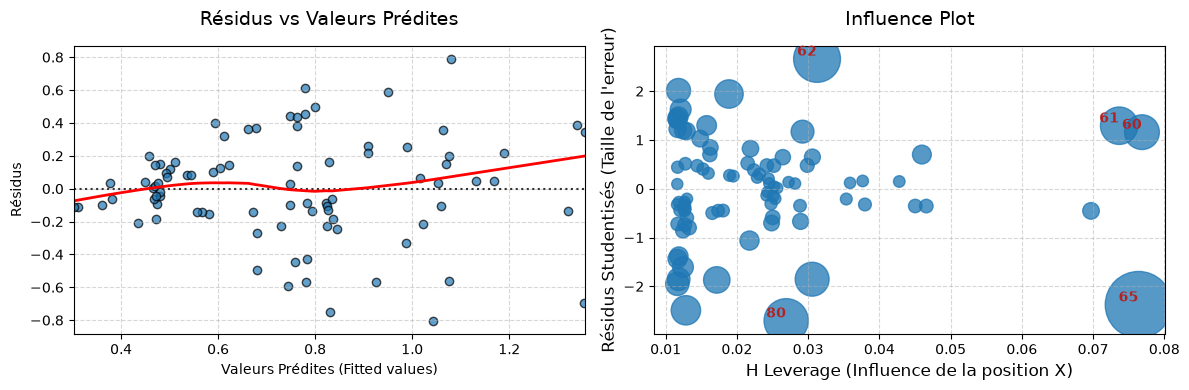

In [9]:
print(f"Corrélation : {df_res.surface_cavite.corr(df_res.surface_gonade)}") # Corrélation

nuage_points(
    x=df_res.surface_cavite, 
    y=df_res.surface_gonade,
    color_var=df_res['position echo'],  # Utilisation de la variable 'position echo' pour colorier les points
    titre="Relation entre la cavité et les gonades", 
    xlabel="Surface de la cavité", 
    ylabel="Surface des gonades",
    couleur='teal'
    )

# Tranformations logarithmiques car non linéaire
linear_regression(df_res.surface_cavite, df_res.surface_gonade)

In [10]:
# On divise en deux les données pour voir si la relation est différente selon la position de l'écho
df_debut = df_res[df_res['position echo'] < 2]
df_fin = df_res[df_res['position echo'] >= 2]

Corrélation : 0.46806051471661425


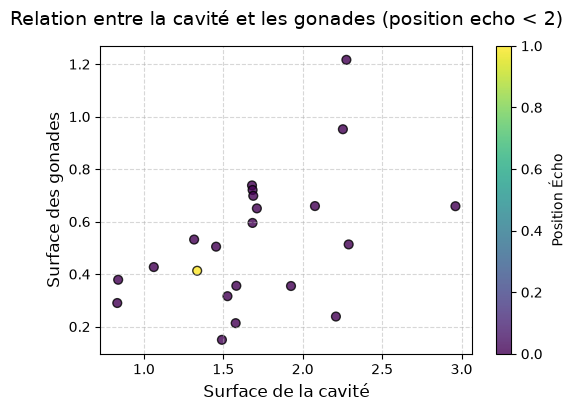

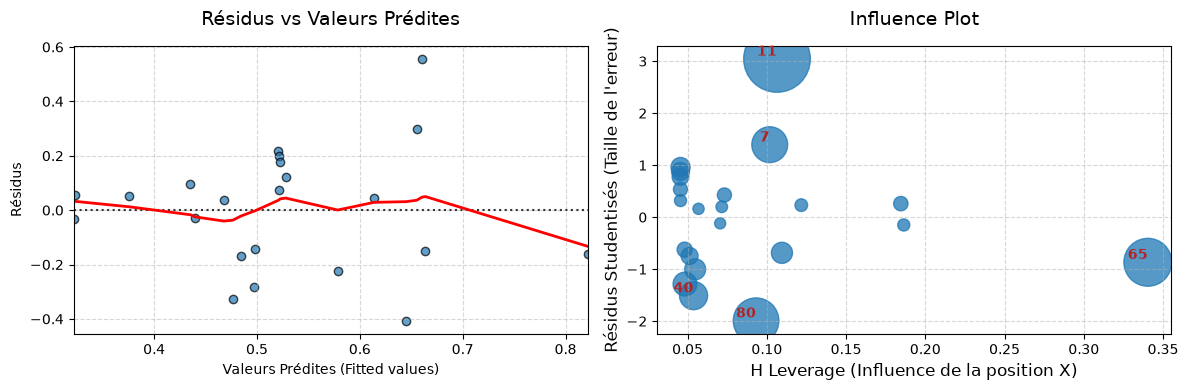

In [11]:
print(f"Corrélation : {df_debut.surface_cavite.corr(df_debut.surface_gonade)}") # Corrélation

nuage_points(
    x=df_debut.surface_cavite, 
    y=df_debut.surface_gonade,
    color_var=df_debut['position echo'],  # Utilisation de la variable 'position echo' pour colorier les points
    titre="Relation entre la cavité et les gonades (position echo < 2)", 
    xlabel="Surface de la cavité", 
    ylabel="Surface des gonades",
    couleur='teal'
    )

# Tranformations logarithmiques car non linéaire
linear_regression(df_debut.surface_cavite, df_debut.surface_gonade)

In [14]:
df_debut.loc[65]

id poisson                     427184.000000
position echo                       0.000000
surface_cavite                      2.961693
surface_gonade                      0.658718
volume_cavite                      18.212769
volume_gonade                       8.699081
echelle                             3.800000
augmentation_surface_gonade         0.000000
augmentation_surface_cavite         0.000000
Name: 65, dtype: float64

Corrélation : 0.8051123292420691


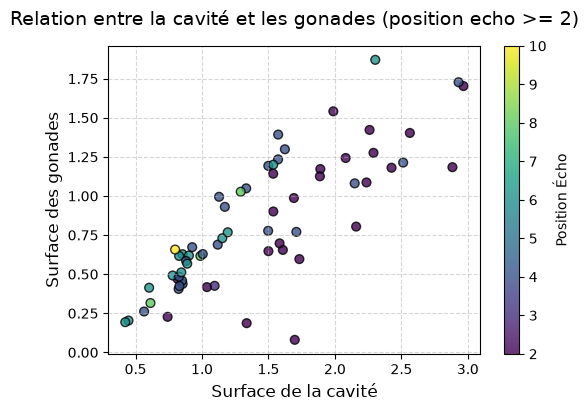

In [15]:
print(f"Corrélation : {df_fin.surface_cavite.corr(df_fin.surface_gonade)}") # Corrélation

nuage_points(
    x=df_fin.surface_cavite, 
    y=df_fin.surface_gonade,
    color_var=df_fin['position echo'],  # Utilisation de la variable 'position echo' pour colorier les points
    titre="Relation entre la cavité et les gonades (position echo >= 2)", 
    xlabel="Surface de la cavité", 
    ylabel="Surface des gonades",
    couleur='teal'
    )

### Détection des anomalies

In [17]:
df_res

,id poisson,position echo,surface_cavite,surface_gonade,volume_cavite,volume_gonade,echelle,augmentation_surface_gonade,augmentation_surface_cavite
0,356302,1.0,1.335455,0.412763,3.824314,1.448392,3.1,0.0,0.0
1,356302,3.0,1.094686,0.425495,3.824314,1.448392,3.1,3.0,-18.0
2,356302,4.0,0.564342,0.261349,3.824314,1.448392,3.1,-39.0,-48.0
3,356418,0.0,1.680767,0.737942,8.699849,5.726512,3.8,0.0,0.0
4,356418,2.0,1.890160,1.172025,8.699849,5.726512,3.8,59.0,12.0
...,...,...,...,...,...,...,...,...,...
81,427276,2.0,2.159730,0.804122,11.408657,4.243235,3.8,237.0,-2.0
82,427276,4.0,1.709827,0.770433,11.408657,4.243235,3.8,-4.0,-21.0
83,427276,6.0,0.844237,0.511352,11.408657,4.243235,3.8,-34.0,-51.0
84,427305,2.0,1.988039,1.540853,3.514411,2.755696,3.8,0.0,0.0


In [18]:
for id in df_res['id poisson'].unique():
    rows = df_res[df_res['id poisson'] == id]
    nb_rows = len(rows)
    pb_list = []

    # Détection des potentiels problèmes de surfaces pour des poissons avec plus de 2 échos
    if nb_rows > 2:
        for i in range(nb_rows):
            # Si l'écho est à Op+2, alors elle ne doit pas avoir une augmentation négative de la surface des gonades
            if rows.iloc[i]["position echo"]==2.0:
                value = rows.iloc[i].augmentation_surface_gonade
                if value < 0 :
                    pb_list.append(1)
                else:
                    pb_list.append(0)

            # Si l'écho est à Op+3 ou plus, alors elle ne doit pas avoir une augmentation de la surface des gonades supérieure à 10%
            elif rows.iloc[i]["position echo"]>2.0:
                value = rows.iloc[i].augmentation_surface_gonade
                if value > 10 :
                    pb_list.append(1)
                else:
                    pb_list.append(0)
            else:
                pb_list.append(0)

        print(f"Poisson : {id} - Problèmes : {pb_list}")

        for i in range(len(pb_list)-1):
            # Si il y a deux "1" à la suite, alors l'erreur est sur la première échographie où il y a un "1"
            if pb_list[i] == 1 and pb_list[i+1] == 1:
                print(f"Poisson : {id} - Problème sur l'écho à la position {rows.iloc[i]['position echo']} (diminution surface gonade : {rows.iloc[i]['augmentation_surface_gonade']})")
                break
        # Si il y a un "1" seul à la deuxième position, alors l'erreur est sur la première échographie
        if pb_list[1] == 1 and pb_list[0] == 0 and pb_list[2] == 0:
            print(f"Poisson : {id} - Problème sur l'écho à la position {rows.iloc[0]['position echo']} (diminution surface gonade : {rows.iloc[0]['augmentation_surface_gonade']})")

    else:
        print(f"Poisson : {id} - Pas assez d'échos pour vérifier les augmentations de surface des gonades.")


Poisson : 356302 - Problèmes : [0, 0, 0]
Poisson : 356418 - Problèmes : [0, 0, 0, 0]
Poisson : 356430 - Problèmes : [0, 0, 0, 0]
Poisson : 356434 - Problèmes : [0, 1, 1, 0]
Poisson : 356434 - Problème sur l'écho à la position 2.0 (diminution surface gonade : -3.0)
Poisson : 356859 - Problèmes : [0, 0, 0]
Poisson : 356868 - Problèmes : [0, 0, 0, 0]
Poisson : 356877 - Pas assez d'échos pour vérifier les augmentations de surface des gonades.
Poisson : 356918 - Problèmes : [0, 1, 1]
Poisson : 356918 - Problème sur l'écho à la position 2.0 (diminution surface gonade : -75.0)
Poisson : 356948 - Problèmes : [0, 0, 0, 0]
Poisson : 356970 - Problèmes : [0, 1, 1]
Poisson : 356970 - Problème sur l'écho à la position 2.0 (diminution surface gonade : -65.0)
Poisson : 357291 - Problèmes : [0, 0, 0, 0]
Poisson : 357302 - Pas assez d'échos pour vérifier les augmentations de surface des gonades.
Poisson : 357305 - Problèmes : [0, 0, 0]
Poisson : 426687 - Problèmes : [0, 1, 0]
Poisson : 426687 - Problèm